# S2·LUN — Embeddings: tu primer buscador semántico

**MMIA 6013 · Semana 2 · Lunes**

0. Por qué no se compara con distancias sin normalizar en alta dimensión
1. Generar embeddings de oraciones
2. Similitud coseno y verificación de intuiciones
3. Buscador semántico sobre un mini-corpus
4. Visualización PCA + límites de los embeddings (negación)

Requisitos: `numpy`, `matplotlib`, `scikit-learn` y `sentence-transformers`. La
primera celda instala lo que falte. La Parte 0 corre solo con numpy.

Usa `sentence-transformers` si está instalado; si no, cae a un fallback TF-IDF
para que nadie se quede bloqueado (las conclusiones cualitativas se mantienen).

## 🧑‍🏫 Notas docentes

- La primera ejecución de sentence-transformers descarga el modelo (~120 MB):
  pedir que lo hagan ANTES de clase o proveer red del aula.
- El fallback TF-IDF pierde el efecto "sin palabras compartidas" (par 1 de la
  apuesta): señalarlo si alguien lo usa — es justamente la diferencia entre
  léxico y semántico.
- Momento clave: el par con negación. Conectarlo con "cuándo NO usar embeddings".
- La Parte 0 es explicación, no ejercicio, y corre solo con numpy: sirve para abrir la
  clase mientras el modelo termina de descargarse. Dura unos cinco minutos y su moraleja
  es la que la sesión 06 proyecta en su lámina de las tres medidas: normalizados, coseno
  y euclídea ordenan IGUAL. Lo que se rompe en alta dimensión no es el orden, es el
  umbral absoluto. Si alguien pregunta por qué entonces todo el mundo dice "usa coseno",
  la respuesta honesta es que casi nadie normaliza a mano y el coseno normaliza solo.
- La segunda tabla de la Parte 0 mide el contraste con las DOS métricas a propósito: el
  error frecuente es creer que la maldición de la dimensionalidad se arregla cambiando
  de métrica. No se arregla; lo que la esquiva es que los vectores de un modelo
  entrenado no son puntos al azar.
- La 0.3 es la que convence, y conviene proyectarla: el mismo documento escrito diez mil
  veces más largo da coseno 1 y distancia 554 200. Si alguien viene diciendo "yo uso
  euclídea y me funciona", la respuesta es que le funciona porque su librería normaliza
  sola. Preguntar en voz alta qué pasa cuando alguien indexa el vector de un documento
  SUMANDO los de sus fragmentos en vez de promediarlos: es la forma real de llegar a la
  fila de abajo, y encima rompe el float32 de la 0.4.
- La 0.4 no es trivia numérica: Qdrant, pgvector y FAISS guardan float32. Un coseno de
  1,0000001 rompe cualquier `arccos` y cualquier comparación por igualdad, y es un valor
  que el propio notebook imprime.

In [57]:
# Prerrequisitos. Se instala lo que falte en ESTE intérprete —no en el del sistema— y
# solo si falta: una celda que reinstala en cada corrida gasta los primeros minutos de
# clase. `sentence-transformers` arrastra torch y transformers, así que la primera vez
# tarda varios minutos y baja ~120 MB del modelo: conviene correrla ANTES de clase.
# Si no hay red, el notebook sigue funcionando con el respaldo TF-IDF y la Parte 0 no
# necesita ningún modelo.
import importlib.util
import subprocess
import sys

REQUISITOS = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "sentence_transformers": "sentence-transformers",
}
faltan = [pip for mod, pip in REQUISITOS.items() if importlib.util.find_spec(mod) is None]
if faltan:
    print("instalando:", ", ".join(faltan))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltan], check=False)
    print("listo. Si acabas de instalar sentence-transformers, reinicia el kernel.")
else:
    print("prerrequisitos: todos presentes")

prerrequisitos: todos presentes


In [58]:
import numpy as np
import matplotlib.pyplot as plt

In [45]:
# Motor de embeddings: sentence-transformers con fallback TF-IDF
try:
    from sentence_transformers import SentenceTransformer
    _modelo = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    MOTOR = "sentence-transformers (multilingüe)"

    def embed(textos):
        return np.asarray(_modelo.encode(textos, normalize_embeddings=True))
except ImportError:
    from sklearn.feature_extraction.text import TfidfVectorizer
    MOTOR = "TF-IDF (fallback léxico — instala sentence-transformers para el efecto completo)"
    _tfidf = None

    def embed(textos):
        global _tfidf, _base
        if _tfidf is None:
            raise RuntimeError("Con TF-IDF usa embed_corpus(corpus, consultas) — ver más abajo")
        return _tfidf.transform(textos).toarray()

    def embed_corpus(corpus, consultas):
        global _tfidf
        _tfidf = TfidfVectorizer().fit(corpus + consultas)
        M = _tfidf.transform(corpus + consultas).toarray()
        M = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
        return M[: len(corpus)], M[len(corpus):]

print("Motor de embeddings:", MOTOR)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Motor de embeddings: sentence-transformers (multilingüe)


## Parte 0 — Por qué una distancia euclídea sin normalizar no dice lo que parece

El buscador de hoy compara vectores de **384 dimensiones**. La intuición de distancia
que traemos es de dos o tres, y en alta dimensión se rompe de una forma concreta y
medible. No hay que creerlo: las dos celdas que siguen lo miden.

**El experimento clásico.** Un vector en el origen, `0^d`, y otro en `1^d` —todas sus
coordenadas valen 1—. La distancia entre ambos es `sqrt(d)`. Ahora se le suma a cada
coordenada del segundo un error normal de media 0 y desviación 1, que es el ruido que
tendría un vector "casi igual", y se vuelve a medir.

La pregunta no es si la distancia cambia, sino **cómo cambia con `d`**.

In [46]:
# 0.1 — el origen contra 1^d, y qué le hace un error N(0,1) en cada dimensión
rng = np.random.default_rng(7)
REPETICIONES = 200

# Las cuatro dimensiones grandes no son inventadas: son las de los modelos de la tabla
# semestral del curso. Se leen del JSON si el repositorio está a mano —regla del curso:
# ningún dato de modelo se teclea— y si no, se usan las documentadas con su fecha.
import json
import pathlib

DIMS_DOCUMENTADAS = (384, 1024, 1536, 3072)   # verificadas 2026-08-27 en la tabla semestral
try:
    _tabla = json.loads(
        (pathlib.Path().resolve().parents[2] / "fuentes/modelos/modelos-2026-1.json")
        .read_text(encoding="utf-8"))
    dims_modelos = tuple(sorted({int(e["dimensions"]) for e in _tabla["embeddings"]}))
    print("dimensiones leídas de la tabla semestral:", dims_modelos)
except Exception:
    dims_modelos = DIMS_DOCUMENTADAS
    print("tabla semestral no encontrada; uso las dimensiones documentadas:", dims_modelos)

DIMENSIONES = (2, 8, 32, 128) + dims_modelos

print(f"{'d':>6} {'||1^d||':>9} {'con ruido':>10} {'razón':>7} {'coseno':>8} "
      f"{'||û-v̂||':>9} {'sqrt(2-2cos)':>13}")
for d in DIMENSIONES:
    v = np.ones(d)                                  # el vector "limpio"
    ruido = rng.normal(size=(REPETICIONES, d))      # N(0,1) en cada dimensión
    v_ruido = v + ruido                             # el "casi igual"

    dist_limpia = np.linalg.norm(v)                             # = sqrt(d)
    dist_ruido = np.linalg.norm(v_ruido, axis=1).mean()         # al origen, con ruido
    cos = (v_ruido @ v / (np.linalg.norm(v_ruido, axis=1) * dist_limpia)).mean()

    u_norm = v / dist_limpia
    v_norm = v_ruido / np.linalg.norm(v_ruido, axis=1, keepdims=True)
    dist_norm = np.linalg.norm(v_norm - u_norm, axis=1).mean()

    print(f"{d:>6} {dist_limpia:>9.2f} {dist_ruido:>10.2f} {dist_ruido / dist_limpia:>7.3f} "
          f"{cos:>8.3f} {dist_norm:>9.3f} {np.sqrt(2 - 2 * cos):>13.3f}")

dimensiones leídas de la tabla semestral: (384, 1024, 1536, 3072)
     d   ||1^d||  con ruido   razón   coseno  ||û-v̂||  sqrt(2-2cos)
     2      1.41       1.64   1.160    0.685     0.600         0.793
     8      2.83       3.83   1.354    0.696     0.748         0.780
    32      5.66       7.88   1.392    0.711     0.754         0.761
   128     11.31      15.94   1.409    0.706     0.765         0.766
   384     19.60      27.70   1.414    0.708     0.764         0.764
  1024     32.00      45.25   1.414    0.708     0.764         0.764
  1536     39.19      55.47   1.415    0.708     0.764         0.764
  3072     55.43      78.29   1.413    0.706     0.766         0.766


**Cómo se lee esta tabla.** Tres cosas, y ninguna es la que suele contarse.

1. **La distancia sin normalizar no es comparable entre dimensiones.** El MISMO ruido
   —una normal estándar por coordenada— mueve la distancia 0,23 unidades en `d = 2` y
   casi 23 en `d = 3072`, cien veces más. Un umbral del tipo «si la distancia es menor que 5, son
   parecidos» significa cosas distintas en cada modelo, y deja de significar nada al
   cambiar de modelo. Es el error operativo que esto viene a evitar.
2. **El coseno no se mueve.** Se queda en 0,71 en todas las dimensiones, porque mide
   ángulo y el ángulo no depende de cuántas coordenadas haya. La razón de la columna
   anterior tiende a `sqrt(2)` por lo mismo. (Se mueve entre 0,68 y 0,71: lo que no
   hace es crecer con `d`.) Las cuatro dimensiones grandes son las de los modelos que
   el curso usa de verdad: 384 el del notebook de hoy, 1024 el multilingüe grande,
   1536 y **3072** los dos de OpenAI. En el mayor de ellos el mismo ruido infla la
   distancia casi **23 unidades**, cien veces lo que la infla en `d = 2`.
3. **Y sin embargo, normalizados los dos miden lo mismo:** las dos últimas columnas
   coinciden cifra por cifra, porque `||û - v̂||^2 = 2 - 2·cos(u, v)`. Con vectores de
   norma 1, ordenar por distancia euclídea y ordenar por coseno **dan el mismo
   ranking**. Lo que se rompe no es el orden: es el número absoluto.

Dicho de una vez: el problema no es «euclídea mala, coseno buena». El problema es
comparar magnitudes junto con direcciones, y poner umbrales sobre una escala que
depende de `d`.

In [47]:
# 0.2 — el fenómeno que da nombre a la maldición: el contraste se desploma, y le pasa
# a las DOS métricas. Contraste = (más lejos - más cerca) / más cerca: cuánto se
# distingue el peor candidato del mejor.
N_PUNTOS = 500
print(f"{'d':>6} {'más cerca':>10} {'más lejos':>10} {'contraste':>10} {'ídem coseno':>12}")
for d in DIMENSIONES:
    c_euclideo, c_coseno = [], []
    for _ in range(30):
        X = rng.random((N_PUNTOS, d))
        consulta = rng.random(d)
        dist = np.linalg.norm(X - consulta, axis=1)
        c_euclideo.append((dist.max() - dist.min()) / dist.min())

        Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
        sim = Xn @ (consulta / np.linalg.norm(consulta))
        c_coseno.append((sim.max() - sim.min()) / sim.min())
    print(f"{d:>6} {dist.min():>10.2f} {dist.max():>10.2f} "
          f"{np.mean(c_euclideo):>10.3f} {np.mean(c_coseno):>12.3f}")

     d  más cerca  más lejos  contraste  ídem coseno
     2       0.04       0.88     48.711       13.882
     8       0.43       1.65      3.539        1.668
    32       1.58       2.81      0.854        0.514
   128       4.00       5.40      0.345        0.226
   384       7.43       8.76      0.192        0.127
  1024      12.54      13.98      0.109        0.074
  1536      15.21      16.57      0.089        0.061
  3072      21.98      23.40      0.063        0.043


Con 500 puntos al azar, en `d = 2` el más lejano está decenas de veces más lejos que
el más cercano; en `d = 1536`, menos de un 10 % más lejos. **Todos los puntos quedan a
casi la misma distancia**, y «el vecino más cercano» deja de ser una categoría útil:
eso es la maldición de la dimensionalidad. La última columna es la misma cuenta sobre
el coseno, y se desploma igual: **la maldición no se arregla cambiando de métrica.**

Lo que salva a un buscador de embeddings no es la métrica: es que **los vectores de un
modelo entrenado no son puntos al azar**. Ocupan una región muy pequeña del espacio y
la dirección sí lleva información. Por eso el curso normaliza y compara por coseno, y
por eso los umbrales absolutos se **miden** sobre el corpus propio en vez de copiarse.

### 0.3 — Y ahora al revés: el mismo ángulo, magnitudes cada vez mayores

Hasta aquí los vectores median lo mismo y cambiaba `d`. Ahora se fija `d` en 3072 —la
mayor de la tabla— y se multiplica el vector por 10, 100, 1000 y 10 000, **sin girarlo
ni un grado**. Es el caso que separa de verdad a las dos medidas: la dirección no
cambia, solo el tamaño.

In [48]:
# 0.3 — misma dirección, magnitud creciente. float32 porque es lo que guarda una base
# vectorial: Qdrant, pgvector y FAISS almacenan float32, no float64.
D_GRANDE = max(DIMENSIONES)
ESCALAS = (1, 10, 100, 1000, 10000)

u = np.ones(D_GRANDE, dtype=np.float32)
print(f"a) el mismo vector, solo que más largo   (d = {D_GRANDE})")
print(f"{'escala':>8} {'||v||':>12} {'||u - v||':>14} {'cos(u, v)':>14}")
for s in ESCALAS:
    v = (s * np.ones(D_GRANDE)).astype(np.float32)
    cos = float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))
    print(f"{s:>8} {np.linalg.norm(v):>12.1f} {np.linalg.norm(u - v):>14.1f} {cos:>14.8f}")

print()
print("b) el mismo vector largo, con el MISMO ruido N(0,1) de antes")
print(f"{'escala':>8} {'||v||':>12} {'||v - v_ruido||':>16} {'cos':>12} {'dist/||v||':>12}")
for s in ESCALAS:
    v = (s * np.ones(D_GRANDE)).astype(np.float32)
    v_ruido = (v + rng.normal(size=D_GRANDE)).astype(np.float32)
    dist = float(np.linalg.norm(v - v_ruido))
    cos = float(v @ v_ruido / (np.linalg.norm(v) * np.linalg.norm(v_ruido)))
    print(f"{s:>8} {np.linalg.norm(v):>12.1f} {dist:>16.2f} {cos:>12.8f} "
          f"{dist / np.linalg.norm(v):>12.5f}")

a) el mismo vector, solo que más largo   (d = 3072)
  escala        ||v||      ||u - v||      cos(u, v)
       1         55.4            0.0     1.00000000
      10        554.3          498.8     0.99999994
     100       5542.6         5487.1     1.00000000
    1000      55425.6        55370.2     1.00000000
   10000     554256.2       554200.9     1.00000012

b) el mismo vector largo, con el MISMO ruido N(0,1) de antes
  escala        ||v||  ||v - v_ruido||          cos   dist/||v||
       1         55.4            55.85   0.70918185      1.00759
      10        554.3            55.32   0.99505907      0.09981
     100       5542.6            55.82   0.99994934      0.01007
    1000      55425.6            55.51   0.99999958      0.00100
   10000     554256.2            55.32   1.00000012      0.00010


**La tabla (a) es el experimento decisivo.** `u` y `v` apuntan exactamente al mismo
sitio: son el mismo documento, uno escrito diez mil veces más largo. El coseno dice
`1,0` en las cinco filas —idénticos en dirección, que es lo que responde a «¿hablan de
lo mismo?»; el temblor de la séptima cifra lo explica la celda siguiente— y
la distancia euclídea dice **554 200**, que leída como «se parecen poco» es una
respuesta falsa. Una medida sin normalizar **mezcla de qué habla un texto con cuánto
texto hay**, y en un corpus real las longitudes varían por dos órdenes de magnitud.

**La tabla (b) es la misma trampa, más fina.** El ruido es el de siempre y la distancia
entre el vector y su copia ruidosa se queda en unas 55 unidades en las cinco filas. El
mismo 55 significa cosas opuestas: con escala 1 es **la longitud entera** del vector
—son dos cosas distintas— y con escala 10 000 es el **0,01 %** de ella —son la misma—.
El coseno lo dice bien en las cinco: 0,70 arriba, 1,00 abajo. Un umbral absoluto sobre
la distancia no puede acertar en las dos filas a la vez; el coseno no necesita umbral
para ordenar.

**¿Y dónde se distorsiona el coseno?** No por geometría: es invariante de escala por
construcción, y por eso aguanta las cinco filas. Se distorsiona por **aritmética**, y
la celda siguiente enseña dónde.

In [49]:
# 0.4 — el límite que sí tiene el coseno, y es del float32
print(f"{'escala':>10} {'||v|| (float32)':>18} {'cos(v, v)':>22}")
for s in (1e4, 1e8, 1e16, 1e18, 1e20):
    v = (s * np.ones(D_GRANDE)).astype(np.float32)
    n = np.linalg.norm(v)
    cos = float(v @ v / (n * n)) if np.isfinite(n) and n > 0 else float("nan")
    print(f"{s:>10.0e} {n:>18.4g} {cos:>22}")

    escala    ||v|| (float32)              cos(v, v)
     1e+04          5.543e+05                    1.0
     1e+08          5.543e+09     1.0000001192092896
     1e+16          5.543e+17     1.0000001192092896
     1e+18                inf                    nan
     1e+20                inf                    nan


El coseno de un vector **consigo mismo** tiene que ser exactamente 1. En float32 ya
devuelve `1.0000001` a partir de escalas del orden de 10⁸ —un valor imposible, que
rompe cualquier `arccos` y cualquier comparación `== 1`— y a partir de 10¹⁸ el producto
punto desborda el float32, la norma sale `inf` y la similitud sale `nan`.

**Ningún modelo de embeddings llega ahí:** los vectores que produce el del notebook
tienen norma de orden 1. Se llega si se alimenta la base con recuentos crudos, con
sumas de vectores sin promediar o con datos sin escalar, que es exactamente lo que pasa
cuando alguien indexa «el vector del documento» sumando los de sus fragmentos. La
conclusión operativa del día cabe en una línea: **normalizar al indexar**, que pone
todas las normas en 1, elimina las cinco filas de este problema de un golpe y deja
coseno, producto punto y orden euclídeo diciendo lo mismo.

## Parte 1 — Similitud coseno

### ✏️ Ejercicio 1.1
Implementa `similitud_coseno(a, b)` para dos vectores 1-D.
Luego verifica: como `embed()` normaliza, debe coincidir con `a @ b`.

In [50]:
# Ejercicio 1.1 — coseno = (a·b) / (||a|| ||b||)
def similitud_coseno(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

a, b = np.array([1.0, 0.0]), np.array([1.0, 1.0])
print(f"cos([1,0],[1,1]) = {similitud_coseno(a, b):.4f} (esperado ≈ 0.7071)")
assert abs(similitud_coseno(a, b) - 1 / np.sqrt(2)) < 1e-9

cos([1,0],[1,1]) = 0.7071 (esperado ≈ 0.7071)


## Parte 2 — La apuesta de clase, medida

¿Cómo ordenaste estos pares? Ahora lo comprobamos.

In [51]:
pares = [
    ("el gato duerme en el sofá", "un felino descansa en el mueble"),
    ("el gato duerme en el sofá", "el gato no duerme en el sofá"),
    ("el gato duerme en el sofá", "python lanza una excepción"),
    ("¿cómo facturo con RUC?", "pasos para emitir factura electrónica"),
]

try:
    textos = [t for p in pares for t in p]
    V = embed(textos)
    for i, (t1, t2) in enumerate(pares):
        s = similitud_coseno(V[2 * i], V[2 * i + 1])
        print(f"{s:.3f}  «{t1}» ↔ «{t2}»")
except RuntimeError as e:
    print(e)

0.687  «el gato duerme en el sofá» ↔ «un felino descansa en el mueble»
0.854  «el gato duerme en el sofá» ↔ «el gato no duerme en el sofá»
0.033  «el gato duerme en el sofá» ↔ «python lanza una excepción»
0.253  «¿cómo facturo con RUC?» ↔ «pasos para emitir factura electrónica»


**Discute:** ¿la negación (par 2) quedó donde esperabas? Para un modelo de
embeddings, "duerme" y "no duerme" son casi la misma frase. Consecuencia:
los embeddings miden *de qué se habla*, no *qué se afirma*.

## Parte 3 — Buscador semántico sobre FAQs

In [52]:
faqs = [
    "Para resetear tu contraseña entra a Configuración > Seguridad y pulsa 'Olvidé mi clave'.",
    "Los reembolsos se procesan en 5 a 7 días hábiles tras aprobar la solicitud.",
    "Puedes exportar tus datos en formato CSV desde el panel de administración.",
    "La factura electrónica se emite automáticamente al confirmar el pago.",
    "Para cancelar tu suscripción ve a Cuenta > Plan y selecciona 'Cancelar'.",
    "El soporte técnico atiende de lunes a viernes de 9h a 18h por chat.",
    "La API permite hasta 100 solicitudes por minuto en el plan básico.",
    "Aceptamos tarjetas de crédito, débito y transferencias bancarias.",
]
consultas = [
    "olvidé mi clave de acceso",
    "¿cuándo me devuelven el dinero?",
    "límite de requests de la api",
]

In [53]:
# Ejercicio 3.1 — implementa buscar(consulta, k=2): embebe corpus y consulta,
# calcula similitudes y devuelve los k documentos más cercanos con su score.
if MOTOR.startswith("sentence"):
    V_corpus = embed(faqs)
    V_consultas = embed(consultas)
else:
    V_corpus, V_consultas = embed_corpus(faqs, consultas)

def buscar(idx_consulta: int, k: int = 2):
    scores = V_corpus @ V_consultas[idx_consulta]      # vectores normalizados → dot = coseno
    top = np.argsort(scores)[::-1][:k]
    return [(float(scores[i]), faqs[i]) for i in top]

for qi, q in enumerate(consultas):
    print(f"\n🔎 «{q}»")
    for score, doc in buscar(qi):
        print(f"   {score:.3f}  {doc}")


🔎 «olvidé mi clave de acceso»
   0.775  Para resetear tu contraseña entra a Configuración > Seguridad y pulsa 'Olvidé mi clave'.
   0.149  Para cancelar tu suscripción ve a Cuenta > Plan y selecciona 'Cancelar'.

🔎 «¿cuándo me devuelven el dinero?»
   0.393  Los reembolsos se procesan en 5 a 7 días hábiles tras aprobar la solicitud.
   0.291  Aceptamos tarjetas de crédito, débito y transferencias bancarias.

🔎 «límite de requests de la api»
   0.246  Los reembolsos se procesan en 5 a 7 días hábiles tras aprobar la solicitud.
   0.243  La API permite hasta 100 solicitudes por minuto en el plan básico.


Con sentence-transformers, «olvidé mi clave de acceso» encuentra la FAQ de
contraseña **sin compartir casi ninguna palabra**. Eso es retrieval denso.
(Con el fallback TF-IDF verás que necesita palabras compartidas: esa es la
diferencia entre búsqueda léxica y semántica.)

## Parte 4 — Visualizar el espacio con PCA

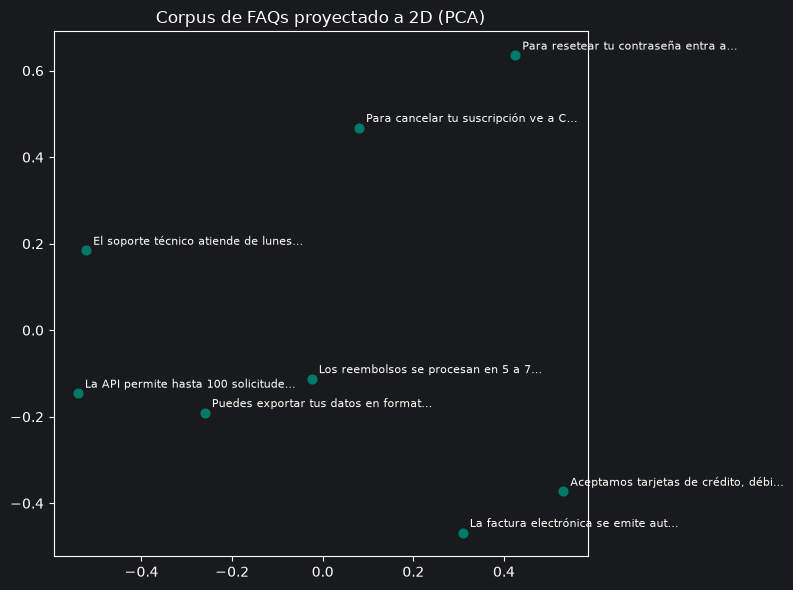

In [54]:
# Ejercicio 4.1 — proyecta los embeddings del corpus a 2D con PCA y grafícalos
# etiquetados. ¿Los temas (cuenta/pagos/soporte/api) quedan agrupados?
from sklearn.decomposition import PCA

X2 = PCA(n_components=2).fit_transform(V_corpus)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X2[:, 0], X2[:, 1], s=40, color="#00796B")
for i, doc in enumerate(faqs):
    ax.annotate(doc[:35] + "…", (X2[i, 0], X2[i, 1]), fontsize=8,
                xytext=(5, 4), textcoords="offset points")
ax.set_title("Corpus de FAQs proyectado a 2D (PCA)")
plt.tight_layout()
plt.show()

⚠️ PCA de 384 → 2 dimensiones pierde muchísima estructura: úsalo como
intuición, nunca como evidencia. La similitud real se mide en el espacio completo.

## Parte 5 — Dos cosas que el sábado te pasarán sin aviso

### ✏️ Ejercicio 5.1 — El techo de 128 tokens, visto
`paraphrase-multilingual-MiniLM-L12-v2` corta la entrada a `max_seq_length` tokens
**sin avisar** (fuentes/modelos/modelos-2026-1.json, fila `embed_notebook_s2`, 128
tokens, verificado 2026-08-27). Toma un texto de ~900 palabras —el `chunk_size` que
trae el Lab 02—, cuenta sus tokens con el tokenizador del modelo, y compara el
vector del texto entero con el del texto recortado a los primeros `max_seq_length`
tokens. Si el coseno es ≈ 1, todo lo demás nunca llegó al índice.

In [55]:
# Ejercicio 5.1 — el truncado silencioso, medido sobre el modelo real
if MOTOR.startswith("sentence"):
    tope = _modelo.max_seq_length
    largo = (" ".join(faqs) + " ") * 8            # ~800 palabras, del orden del chunk del lab
    tok = _modelo.tokenizer
    ids = tok(largo, add_special_tokens=True, truncation=False)["input_ids"]
    recorte = tok.decode(ids[1:tope - 1])          # lo que el modelo alcanza a ver
    v_todo, v_recorte = embed([largo, recorte])
    print(f"tokens del texto: {len(ids)} · max_seq_length del modelo: {tope}")
    print(f"coseno(texto entero, recortado a {tope} tokens) = {float(v_todo @ v_recorte):.4f}")
    print("→ el sábado: chunk_size en TOKENS y por debajo de este tope, o leer el tope del modelo")
else:
    print("El ejercicio 5.1 necesita sentence-transformers: el truncado es del modelo, no de TF-IDF")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1106 > 128). Running this sequence through the model will result in indexing errors


tokens del texto: 1106 · max_seq_length del modelo: 128
coseno(texto entero, recortado a 128 tokens) = 1.0000
→ el sábado: chunk_size en TOKENS y por debajo de este tope, o leer el tope del modelo


### ✏️ Ejercicio 5.2 — Quita la normalización y mira qué cambia
Repite la búsqueda de la Parte 3 con `normalize_embeddings=False` y compara el
ranking con el de antes. Sin normalizar, `@` ya no es el coseno: premia la norma del
vector, no el ángulo.

In [56]:
# Ejercicio 5.2 — sin normalizar, el producto punto mezcla ángulo y norma
if MOTOR.startswith("sentence"):
    Vc_raw = np.asarray(_modelo.encode(faqs, normalize_embeddings=False))
    Vq_raw = np.asarray(_modelo.encode(consultas, normalize_embeddings=False))
    normas = np.linalg.norm(Vc_raw, axis=1)
    for qi, q in enumerate(consultas):
        antes = [faqs.index(d) for _, d in buscar(qi, k=3)]
        ahora = [int(i) for i in np.argsort(Vc_raw @ Vq_raw[qi])[::-1][:3]]
        print(f"«{q}»\n   normalizado: {antes}   crudo: {ahora}   normas del crudo: {normas[ahora].round(2)}")
else:
    print("El ejercicio 5.2 necesita sentence-transformers")

«olvidé mi clave de acceso»
   normalizado: [0, 4, 5]   crudo: [0, 4, 5]   normas del crudo: [4.09 3.77 4.04]
«¿cuándo me devuelven el dinero?»
   normalizado: [1, 7, 0]   crudo: [1, 7, 0]   normas del crudo: [3.86 4.5  4.09]
«límite de requests de la api»
   normalizado: [1, 6, 5]   crudo: [6, 1, 5]   normas del crudo: [4.8  3.86 4.04]


## Cierre

- Embedding: texto → vector; cerca = parecido (entrenamiento contrastivo).
- Normalizar permite usar dot como coseno.
- Fortaleza: sinónimos y paráfrasis. Debilidades: negación, identificadores exactos.

**Mañana:** ¿qué pasa cuando el corpus tiene 10 millones de vectores y el kNN
exacto tarda segundos? Índices ANN: HNSW e IVF, y Qdrant.